In [1]:
import os 
import numpy as np
import h5py as h5
import MDAnalysis as mda
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import pickle as pkl

from MDAnalysis.transformations import unwrap, center_in_box, wrap
from MDAnalysis.analysis import align

os.chdir('/media/volume/Orai1_rep0/Orai1_analysis')

/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
rep0_yh = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-1/Tyr208_His57.h5', 'r')
rep1_yh = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-2/Tyr208_His57.h5', 'r')
rep2_yh = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-3/Tyr208_His57.h5', 'r')

rep0_yf = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-1/Tyr208_Phe53.h5', 'r')
rep1_yf = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-2/Tyr208_Phe53.h5', 'r')
rep2_yf = h5.File('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/structural/Rep-3/Tyr208_Phe53.h5', 'r')

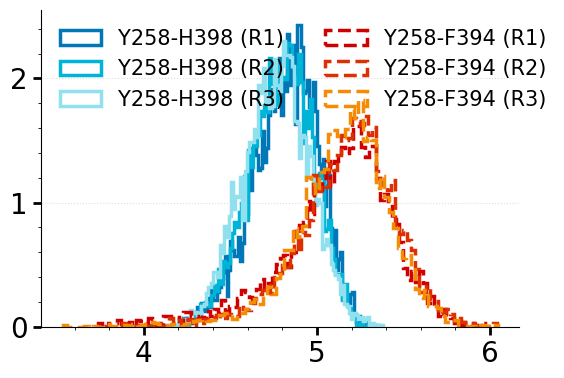

In [9]:
# Global font settings
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(6, 4))

fts = 20

# Define color families
# Blues/Teals for Y258---H398
colors_yh = ['#0077b6', '#00b4d8', '#90e0ef'] 
# Reds/Oranges for Y258---F394
colors_yf = ['#d00000', '#dc2f02', '#f48c06'] 

hist_kwargs = {'bins': 100, 'histtype': 'step', 'density': True, 'linewidth': 2.5}

# 1. Plot Y258---H398 (Solid Lines - Blue Palette)
ax.hist(rep0_yh['distance'], color=colors_yh[0], label='Y258-H398 (R1)', **hist_kwargs)
ax.hist(rep1_yh['distance'], color=colors_yh[1], label='Y258-H398 (R2)', **hist_kwargs)
ax.hist(rep2_yh['distance'], color=colors_yh[2], label='Y258-H398 (R3)', **hist_kwargs)

# 2. Plot Y258---F394 (Dashed Lines - Red Palette)
# Using dashed lines here adds an extra layer of clarity
ax.hist(rep0_yf['distance'], color=colors_yf[0], label='Y258-F394 (R1)', linestyle='--', **hist_kwargs)
ax.hist(rep1_yf['distance'], color=colors_yf[1], label='Y258-F394 (R2)', linestyle='--', **hist_kwargs)
ax.hist(rep2_yf['distance'], color=colors_yf[2], label='Y258-F394 (R3)', linestyle='--', **hist_kwargs)

# --- Aesthetic Improvements ---

#ax.set_xlabel('Distance (Å)', fontsize=16, fontweight='bold', labelpad=10)
#ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold', labelpad=10)

# Professional ticks
ax.tick_params(axis='both', which='major', labelsize=fts, length=6, width=2)

ax.minorticks_on()

# Legend - Split into two columns for clarity
ax.legend(frameon=False, fontsize=fts - 5, loc='upper left', ncol=2)

# Grid and Final Touch
ax.grid(axis='y', linestyle=':', alpha=0.4)
sns.despine()

plt.tight_layout()

plt.savefig('Manuscript/Raw/Fig7/Y258-F394-H398.png', dpi=600)
plt.show()

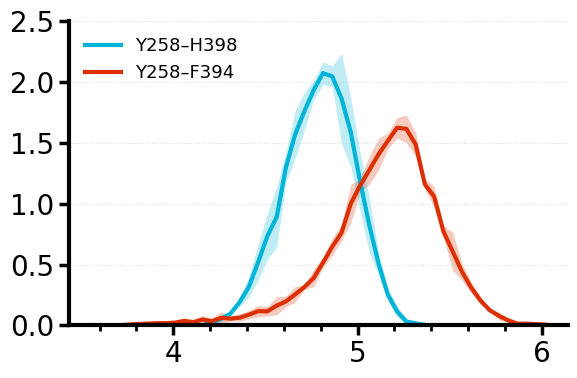

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})
fts = 20

fig, ax = plt.subplots(figsize=(6, 4))

CONTACTS = {
    'Y258–H398': ('#00b4d8', [rep0_yh, rep1_yh, rep2_yh]),
    'Y258–F394': ('#dc2f02', [rep0_yf, rep1_yf, rep2_yf]),
}

NBINS = 50

def get_vals(f):
    return np.asarray(f['distance'])

# common bin edges across everything, so the two contacts are comparable
all_vals = np.concatenate([get_vals(f)
                           for _, reps in CONTACTS.values()
                           for f in reps])
edges = np.linspace(all_vals.min(), all_vals.max(), NBINS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

for name, (color, reps) in CONTACTS.items():
    dens = np.vstack([np.histogram(get_vals(f), bins=edges, density=True)[0]
                      for f in reps])
    mean = dens.mean(axis=0)
    sd = dens.std(axis=0, ddof=1)          # n-1 across the three replicas

    ax.plot(centers, mean, color=color, linewidth=3, label=name)
    ax.fill_between(centers, np.maximum(mean - sd, 0), mean + sd,
                    color=color, alpha=0.25, linewidth=0)

#ax.set_xlabel('Distance (Å)', fontsize=fts)
#ax.set_ylabel('Probability density', fontsize=fts)
ax.set_ylim(top=2.5)
ticks = list(ax.get_yticks()) + [2.5]
ax.set_yticks(sorted(set(ticks)))
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(3)
ax.set_ylim(bottom=0)
ax.minorticks_on()
ax.tick_params(axis='y', which='minor', left=False, top=False)
ax.tick_params(axis='both', which='major', labelsize=fts, length=7, width=2.5)
ax.tick_params(axis='x', which='minor', length=4, width=2.0)

ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.legend(frameon=False, fontsize=fts - 7, loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('Manuscript/Raw/Fig7/Y258-F394-H398.png', dpi=600,
            bbox_inches='tight')
plt.show()

Curves show the probability density of the interatomic distance, averaged across three independent replicas. Shaded bands indicate ± 1 standard deviation across replicas at each bin.